<a href="https://colab.research.google.com/github/anushah-200/factcheckAI/blob/main/notebooks/10_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

sns.set_style("whitegrid")

In [2]:
base_path = "/content/drive/MyDrive/factcheckAI/outputs/"

In [3]:
#loading training data
X_train = pd.read_csv(base_path + "X_train.csv")

X_test = pd.read_csv(base_path + "X_test.csv")
y_train = pd.read_csv(base_path + "y_train.csv")

y_test = pd.read_csv(base_path + "y_test.csv")

In [4]:
#converting labels
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [5]:
print("Training shape:")
print(X_train.shape)

print("\nTesting shape:")
print(X_test.shape)


print("\nFeatures:")
print(X_train.columns)

Training shape:
(644, 7)

Testing shape:
(162, 7)

Features:
Index(['Category', 'Type', 'Model', 'ResponseLength', 'QuestionLength',
       'ResponseCharacters', 'AverageWordLength'],
      dtype='object')


In [6]:
print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)

print("Testing Labels:", y_test.shape)

Training Features: (644, 7)
Testing Features: (162, 7)
Training Labels: (644,)
Testing Labels: (162,)


In [7]:
#label distribution
print(y_train.value_counts())

Hallucination
1.0    352
0.0    292
Name: count, dtype: int64


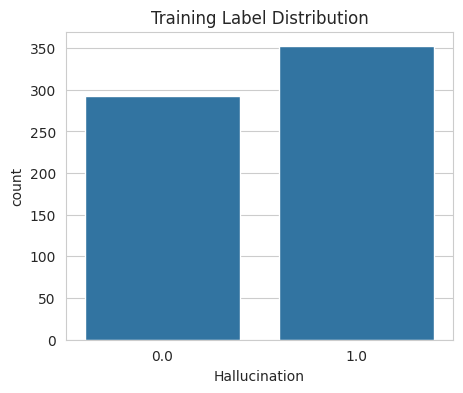

In [8]:
#visualisation
plt.figure(figsize=(5,4))

sns.countplot(
    x=y_train
)

plt.title("Training Label Distribution")

plt.show()

In [9]:
results = []

In [10]:
#training logistic regression
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [11]:
#prediction
y_pred = logistic_model.predict(
    X_test
)

y_prob = logistic_model.predict_proba(
    X_test
)[:,1]

In [12]:
logistic_results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred

})


logistic_results.to_csv(
    base_path+"logistic_predictions.csv",
    index=False
)

print("Logistic Regression predictions saved.")

Logistic Regression predictions saved.


In [13]:
#evaluating logistic regression
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc = roc_auc_score(
    y_test,
    y_prob
)

In [14]:
print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

print("ROC AUC  :", roc)

Accuracy : 0.6851851851851852
Precision: 0.6728971962616822
Recall   : 0.8181818181818182
F1 Score : 0.7384615384615385
ROC AUC  : 0.7076167076167076


In [15]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.71      0.53      0.60        74
         1.0       0.67      0.82      0.74        88

    accuracy                           0.69       162
   macro avg       0.69      0.67      0.67       162
weighted avg       0.69      0.69      0.68       162



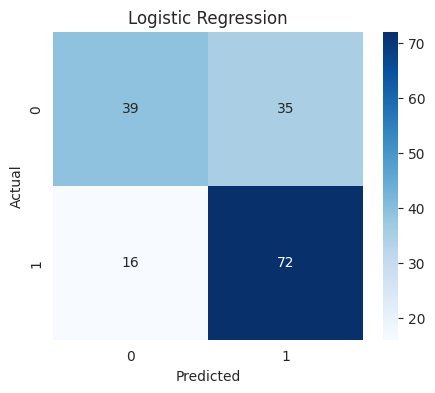

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [17]:
results.append({

    "Model":"Logistic Regression",

    "Accuracy":accuracy,

    "Precision":precision,

    "Recall":recall,

    "F1":f1,

    "ROC-AUC":roc

})

In [18]:
joblib.dump(

    logistic_model,

    "/content/drive/MyDrive/factcheckAI/models/logistic_regression.pkl"

)

['/content/drive/MyDrive/factcheckAI/models/logistic_regression.pkl']

In [19]:
#decision tree
tree = DecisionTreeClassifier(

    random_state=42

)

tree.fit(

    X_train,

    y_train

)

DecisionTreeClassifier(random_state=42)

In [20]:
tree_pred = tree.predict(
    X_test
)

tree_prob = tree.predict_proba(
    X_test
)[:,1]

In [21]:
tree_results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":tree_pred

})


tree_results.to_csv(
    base_path+"decision_tree_predictions.csv",
    index=False
)

In [22]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

tree_precision = precision_score(
    y_test,
    tree_pred
)

tree_recall = recall_score(
    y_test,
    tree_pred
)

tree_f1 = f1_score(
    y_test,
    tree_pred
)

tree_auc = roc_auc_score(
    y_test,
    tree_prob
)

In [23]:
print(classification_report(

    y_test,

    tree_pred

))

              precision    recall  f1-score   support

         0.0       0.83      0.73      0.78        74
         1.0       0.79      0.88      0.83        88

    accuracy                           0.81       162
   macro avg       0.81      0.80      0.80       162
weighted avg       0.81      0.81      0.81       162



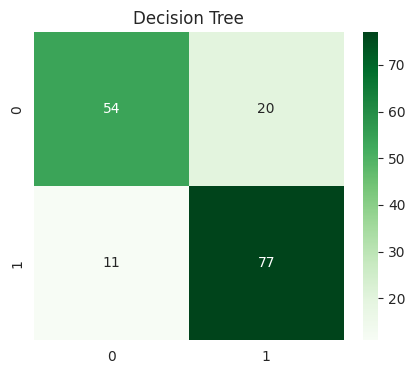

In [24]:
cm = confusion_matrix(
    y_test,
    tree_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    cmap="Greens",

    fmt="d"

)

plt.title("Decision Tree")

plt.show()

In [25]:
results.append({

    "Model":"Decision Tree",

    "Accuracy":tree_accuracy,

    "Precision":tree_precision,

    "Recall":tree_recall,

    "F1":tree_f1,

    "ROC-AUC":tree_auc

})

In [26]:
joblib.dump(

    tree,

    '/content/drive/MyDrive/factcheckAI/models/decision_tree.pkl'
)

['/content/drive/MyDrive/factcheckAI/models/decision_tree.pkl']

In [27]:
#training random forest
forest = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

forest.fit(

    X_train,

    y_train

)

RandomForestClassifier(n_estimators=200, random_state=42)

In [28]:
forest_pred = forest.predict(
    X_test
)

forest_prob = forest.predict_proba(
    X_test
)[:,1]

In [29]:
forest_results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":forest_pred

})


forest_results.to_csv(
    base_path+"random_forest_predictions.csv",
    index=False
)

In [30]:
forest_accuracy = accuracy_score(
    y_test,
    forest_pred
)

forest_precision = precision_score(
    y_test,
    forest_pred
)

forest_recall = recall_score(
    y_test,
    forest_pred
)

forest_f1 = f1_score(
    y_test,
    forest_pred
)

forest_auc = roc_auc_score(
    y_test,
    forest_prob
)

In [31]:
print(classification_report(

    y_test,

    forest_pred

))

              precision    recall  f1-score   support

         0.0       0.87      0.80      0.83        74
         1.0       0.84      0.90      0.87        88

    accuracy                           0.85       162
   macro avg       0.85      0.85      0.85       162
weighted avg       0.85      0.85      0.85       162



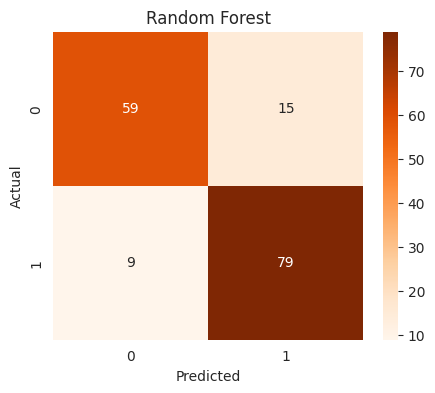

In [32]:
cm = confusion_matrix(
    y_test,
    forest_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Oranges",
    fmt="d"
)

plt.title("Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
results.append({

    "Model":"Random Forest",

    "Accuracy":forest_accuracy,

    "Precision":forest_precision,

    "Recall":forest_recall,

    "F1":forest_f1,

    "ROC-AUC":forest_auc

})

In [34]:
joblib.dump(

    forest,

'/content/drive/MyDrive/factcheckAI/models/random_forest.pkl'


)

['/content/drive/MyDrive/factcheckAI/models/random_forest.pkl']

In [35]:
results_df = pd.DataFrame(results)

results_df
results_df.to_csv(
      base_path+"model_comparison.csv",
      index=False
)

In [36]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.851852,0.840426,0.897727,0.868132,0.920762
1,Decision Tree,0.808642,0.793814,0.875000,0.832432,0.802365
0,Logistic Regression,0.685185,0.672897,0.818182,0.738462,0.707617


In [37]:
results_df.to_csv(
    base_path + "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


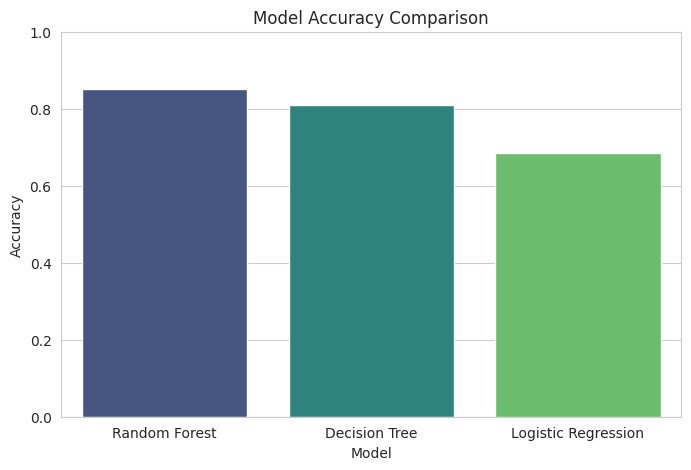

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.show()

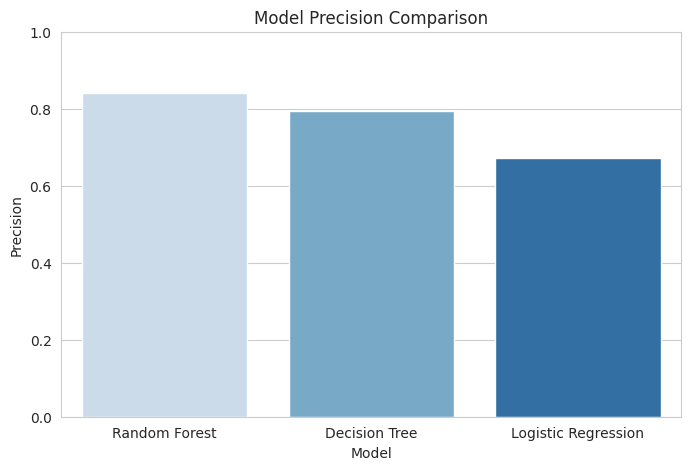

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision",
    hue="Model",
    palette="Blues",
    legend=False
)

plt.title("Model Precision Comparison")

plt.ylim(0,1)

plt.show()

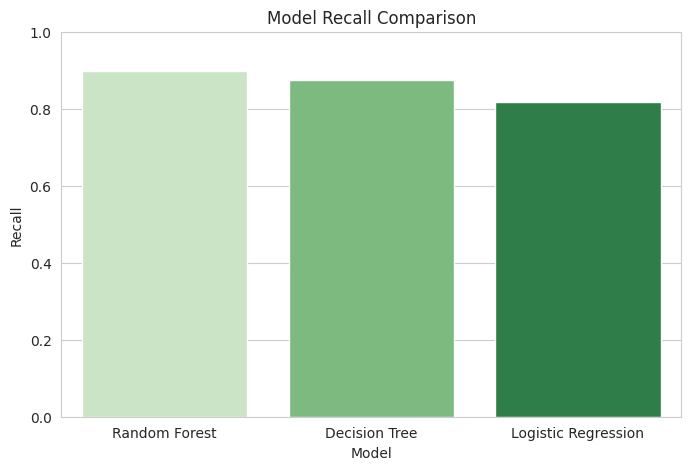

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall",
    hue="Model",
    palette="Greens",
    legend=False
)

plt.title("Model Recall Comparison")

plt.ylim(0,1)

plt.show()

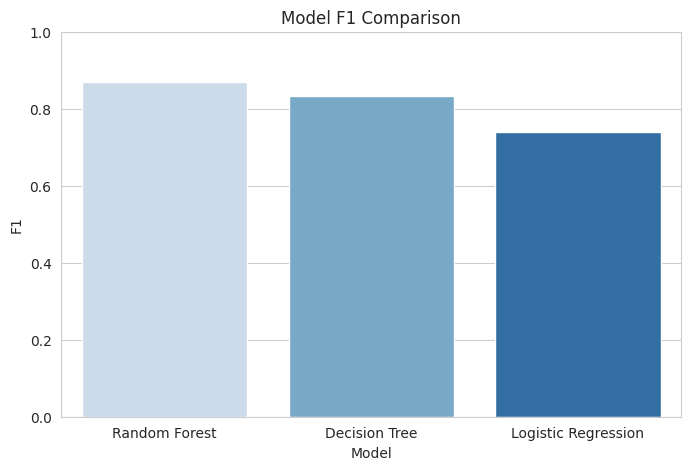

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1",
    hue="Model",
    palette="Blues",
    legend=False
)

plt.title("Model F1 Comparison")

plt.ylim(0,1)

plt.show()

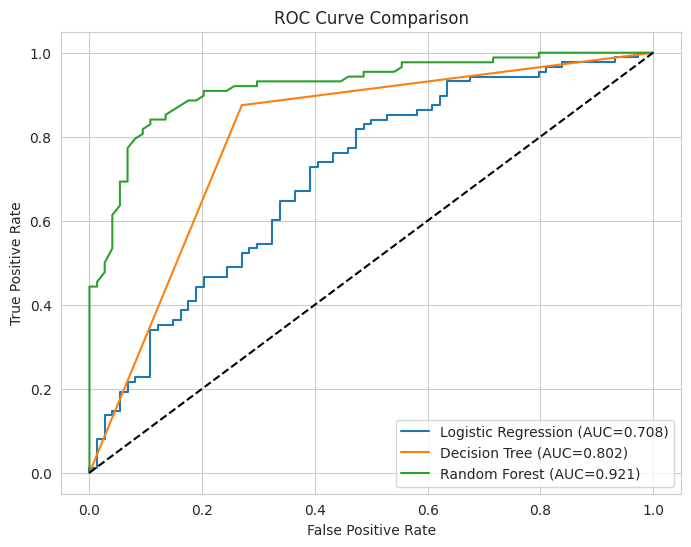

In [42]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC={roc:.3f})"
)

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, tree_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC={tree_auc:.3f})"
)

# Random Forest
fpr, tpr, _ = roc_curve(y_test, forest_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC={forest_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [43]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
0,Category,0.311537
5,ResponseCharacters,0.172587
4,QuestionLength,0.166926
6,AverageWordLength,0.147686
3,ResponseLength,0.135600
2,Model,0.036882
1,Type,0.028781


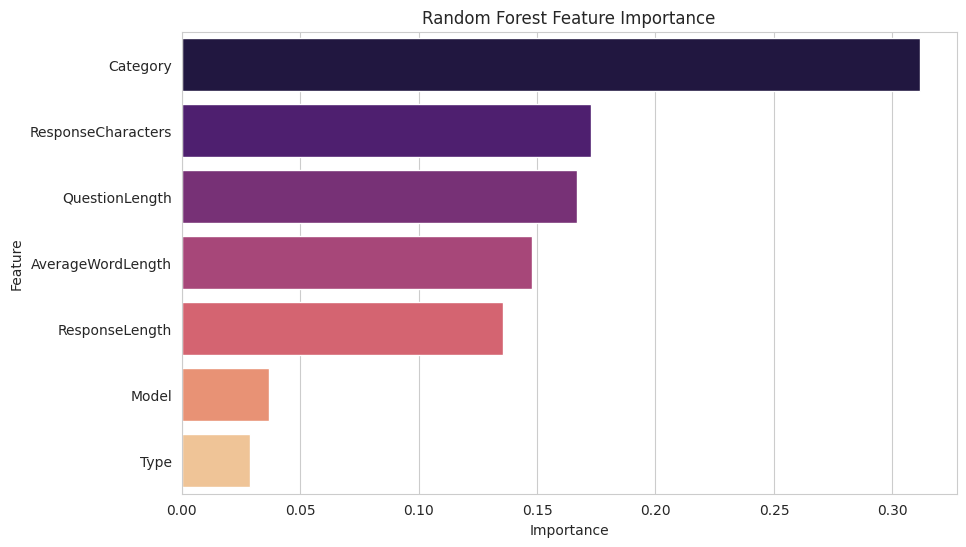

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [45]:
importance.to_csv(
    base_path + "feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


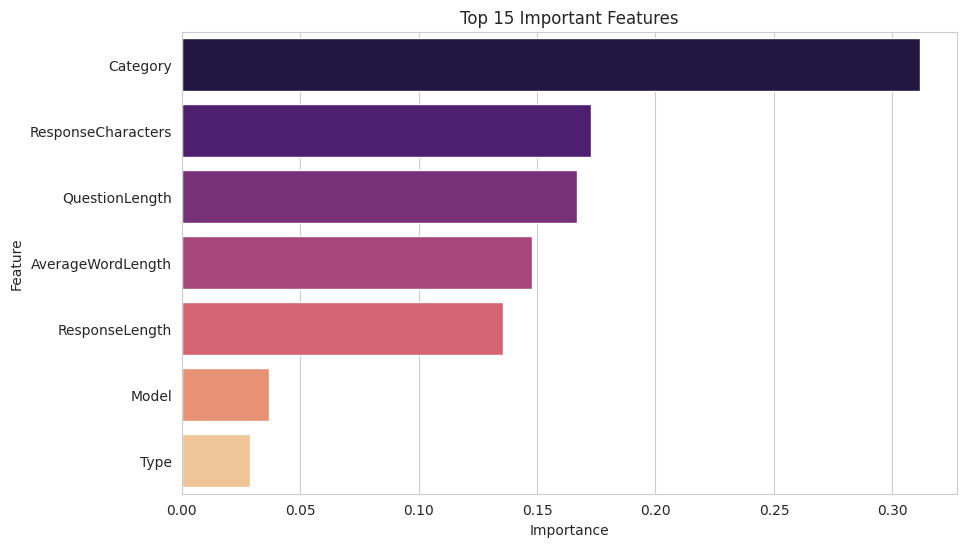

In [46]:
#saving feature importance plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 15 Important Features")

plt.savefig(
    base_path + "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

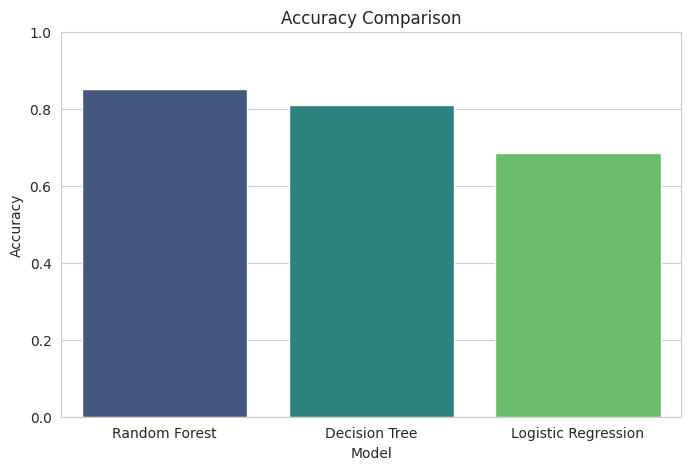

In [47]:
#saving accuracy plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.ylim(0,1)

plt.title("Accuracy Comparison")

plt.savefig(
    base_path + "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

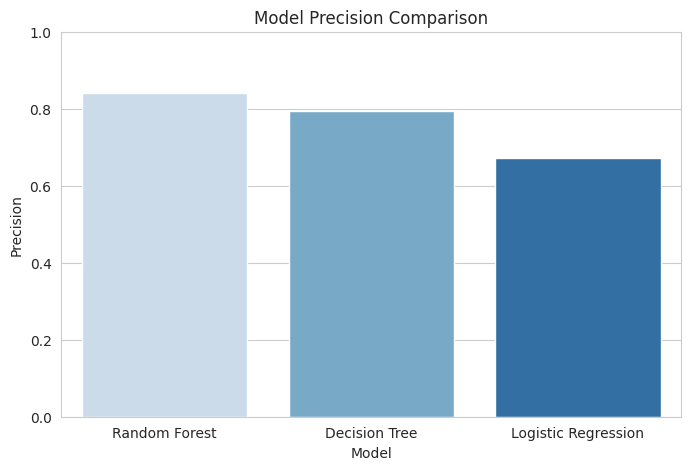

In [48]:
#saving precision plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision",
    hue="Model",
    palette="Blues",
    legend=False
)

plt.title("Model Precision Comparison")

plt.ylim(0,1)
plt.savefig(
    base_path + "precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



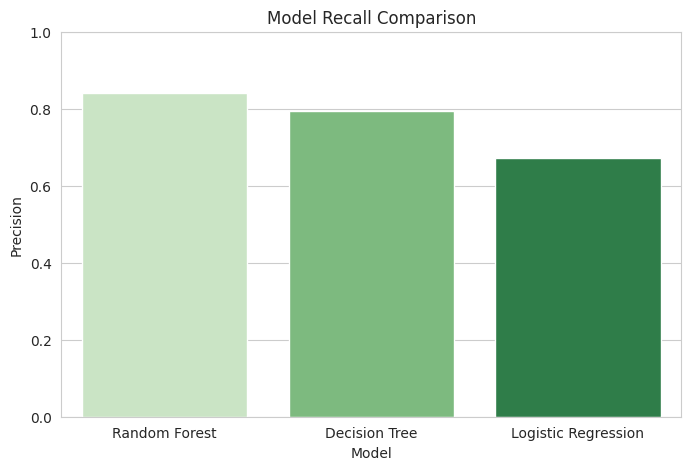

In [49]:
#saving recall plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision",
    hue="Model",
    palette="Greens",
    legend=False
)

plt.title("Model Recall Comparison")

plt.ylim(0,1)
plt.savefig(
    base_path + "Recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

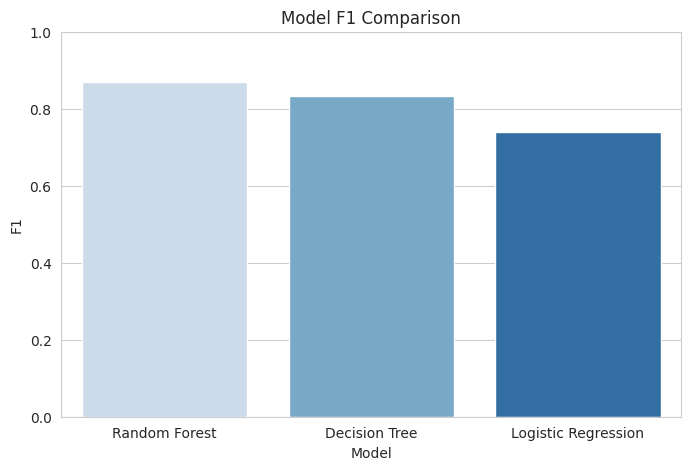

In [50]:
#saving F1 comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1",
    hue="Model",
    palette="Blues",
    legend=False
)

plt.title("Model F1 Comparison")

plt.ylim(0,1)
plt.ylim(0,1)
plt.savefig(
    base_path + "F1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

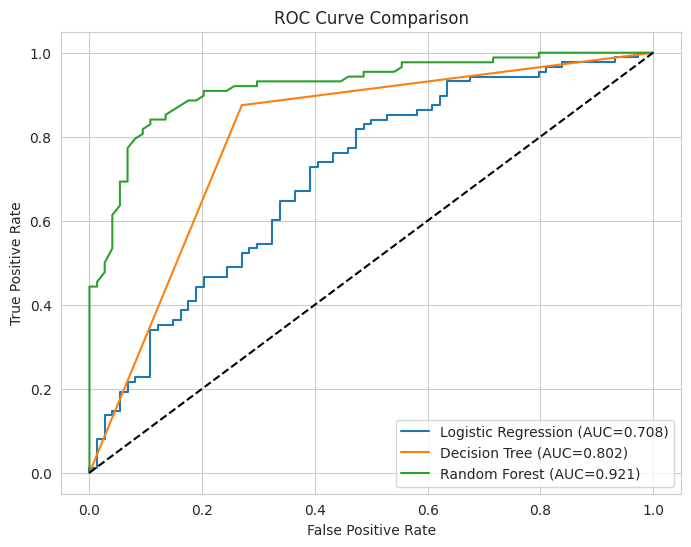

In [61]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC={roc:.3f})"
)

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, tree_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC={tree_auc:.3f})"
)

# Random Forest
fpr, tpr, _ = roc_curve(y_test, forest_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC={forest_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.savefig(
    base_path + "ROC_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
#final results
print("Final Model Performance")

results_df

Final Model Performance


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.851852,0.840426,0.897727,0.868132,0.920762
1,Decision Tree,0.808642,0.793814,0.875000,0.832432,0.802365
0,Logistic Regression,0.685185,0.672897,0.818182,0.738462,0.707617


In [52]:
#best model
best_model = results_df.iloc[0]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model        Random Forest
Accuracy          0.851852
Precision         0.840426
Recall            0.897727
F1                0.868132
ROC-AUC           0.920762
Name: 2, dtype: object


In [53]:
#verifying output folder
import os

os.listdir(base_path)

['model_metric_summary.csv',
 'potential_hallucinations.csv',
 'category_metric_summary.csv',
 'metric_summary.csv',
 'responses_test.csv',
 'groq_responses.csv',
 'deepseek_responses.csv',
 'openai_responses.csv',
 'evaluation_checkpoint.csv',
 'merged_responses.csv',
 'evaluation_dataset.csv',
 'manual_annotation_sample.csv.gsheet',
 'manual_annotation_sample.csv',
 'manual_review.csv',
 'high_confidence_labels.csv',
 'uncertain_responses.csv',
 'ml_dataset.csv',
 'training_dataset.csv',
 'model_encoder.pkl',
 'scaler.pkl',
 'feature_names.pkl',
 'logistic_regression.pkl',
 'random_forest.pkl',
 'decision_tree.pkl',
 'validated_model_comparison.csv',
 'error_analysis_day11.csv',
 'false_positive_day11.csv',
 'false_negative_day11.csv',
 'validated_feature_importance.csv',
 'logistic_predictions.csv',
 'model_comparison.csv',
 'random_forest_predictions.csv',
 'decision_tree_predictions.csv',
 'feature_importance.csv',
 'feature_importance.png',
 'accuracy_comparison.png',
 'category_

In [54]:
#inspecting the features used
print(X_train.columns.tolist())

['Category', 'Type', 'Model', 'ResponseLength', 'QuestionLength', 'ResponseCharacters', 'AverageWordLength']



A target leakage issue was identified during preprocessing because some features had a direct relationship with the target variable generation process. Including such features could allow the model to learn the labeling mechanism rather than generalizable patterns from the data. Therefore, these features were excluded to ensure a more reliable evaluation of the model performance.

In [55]:
#error analysis

In [56]:
predictions = pd.DataFrame({

    "Actual": y_test,

    "Predicted": forest_pred,

    "Probability": forest_prob

})

predictions.head()

,Actual,Predicted,Probability
0,1.0,1.0,0.880
1,1.0,1.0,0.755
2,1.0,1.0,0.740
3,1.0,1.0,0.575
4,1.0,1.0,0.665


In [57]:
#false positives
false_positive = predictions[
    (predictions["Actual"] == 0) &
    (predictions["Predicted"] == 1)
]

print("False Positives:", len(false_positive))

false_positive.head()

False Positives: 15


,Actual,Predicted,Probability
13,0.0,1.0,0.580
22,0.0,1.0,0.570
29,0.0,1.0,0.700
31,0.0,1.0,0.770
50,0.0,1.0,0.535


In [58]:
false_negative = predictions[
    (predictions["Actual"] == 1) &
    (predictions["Predicted"] == 0)
]

print("False Negatives:", len(false_negative))

false_negative.head()

False Negatives: 9


,Actual,Predicted,Probability
23,1.0,0.0,0.465
37,1.0,0.0,0.350
51,1.0,0.0,0.290
77,1.0,0.0,0.495
94,1.0,0.0,0.175


In [59]:
#saving errors